# Regression analysis

In [1]:
import re
import os
import pandas as pd
from statsmodels.formula.api import ols

In [2]:
data = pd.read_csv('../data/viral/metadata/SARS2_BA1_SPIKE_Dadonaite.csv')
data

,ID,mutant,num_mutations,target,sequence
0,SARS2_BA1_1,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
1,SARS2_BA1_2,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
2,SARS2_BA1_3,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,SARS2_BA1_4,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
4,SARS2_BA1_5,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
...,...,...,...,...,...
10793,SARS2_BA1_10794,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10794,SARS2_BA1_10795,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10795,SARS2_BA1_10796,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10796,SARS2_BA1_10797,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...


In [2]:
mutation = 'N310T'

def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation) # \S for any non- white space
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]

split_mut_sit(mutation)

['N', '310', 'T']

In [4]:
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
data

,ID,mutant,num_mutations,target,sequence,wt,site,mut
0,SARS2_BA1_1,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,I
1,SARS2_BA1_2,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,M
2,SARS2_BA1_3,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,T
3,SARS2_BA1_4,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,V
4,SARS2_BA1_5,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,F,2,F
...,...,...,...,...,...,...,...,...
10793,SARS2_BA1_10794,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,F
10794,SARS2_BA1_10795,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,E
10795,SARS2_BA1_10796,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,C
10796,SARS2_BA1_10797,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,A


In [5]:
model = ols('target ~ site', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     6.196
Date:                Tue, 15 Jul 2025   Prob (F-statistic):               0.00
Time:                        17:19:49   Log-Likelihood:                -12957.
No. Observations:               10798   AIC:                         2.841e+04
Df Residuals:                    9549   BIC:                         3.751e+04
Df Model:                        1248                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.7548      0.427     -4.109   

# Viral

In [3]:
base_dir = '../data/viral/metadata/'
res = {}
for file in os.listdir(base_dir):
    file_path = os.path.join(base_dir, file)
    dts = file.split('.csv')[0]
    data = pd.read_csv(file_path)
    
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]


df = pd.DataFrame.from_dict(res, orient='index').reset_index()
df.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df['Source'] = 'Viral'
df

KeyboardInterrupt: 

## Non-viral

In [ ]:
base_dir = '../data/nonviral/metadata/'
res_nonviral = {}
for file in os.listdir(base_dir):
    dts = file.split('.csv')[0]
    file_path = os.path.join(base_dir, file)
    data = pd.read_csv(file_path)
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data = data.dropna()
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res_nonviral[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]

df2 = pd.DataFrame.from_dict(res_nonviral, orient='index').reset_index()
df2.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df2['Source'] = 'Non-viral'
df2

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,TIM_THETH,0.4950,0.0629,0.5578,Non-viral
1,TIM_THEMA,0.4405,0.0460,0.4836,Non-viral
2,MK01_HUMAN_Johannessen,0.2512,0.0356,0.2861,Non-viral
3,IF1_ECOLI,0.5028,0.0872,0.5903,Non-viral
4,TIM_SULSO,0.4565,0.0691,0.5257,Non-viral
5,RL401_YEAST_Fraser2016,0.4519,0.0630,0.5154,Non-viral
6,RASH_HUMAN_Kuriyan,0.5455,0.0513,0.5948,Non-viral
7,MTH3_HAEAESTABILIZED_Tawfik2015,0.5626,0.0356,0.5813,Non-viral
8,AMIE_PSEAE_Whitehead,0.4708,0.0449,0.5166,Non-viral
9,TPMT_HUMAN_Fowler2018,0.3431,0.1491,0.4886,Non-viral


In [ ]:
res_full = pd.concat([df, df2])
res_melt = res_full.melt(id_vars=['Dataset', 'Source'], value_vars=['R2_site', 'R2_mut', 'R2_site+mut'], var_name='Model', value_name='R2')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,R2_site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,R2_site,0.6027
2,AAV2_CAPSD_Sinai,Viral,R2_site,0.2419
3,IAV_RDRP_Li,Viral,R2_site,0.3660
4,EV_CAPSD_Bakhache,Viral,R2_site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Non-viral,R2_site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Non-viral,R2_site+mut,0.4354
234,RL401_YEAST_Bolon2013,Non-viral,R2_site+mut,0.5773
235,RL401_YEAST_Bolon2014,Non-viral,R2_site+mut,0.5871


In [ ]:
#res_melt.to_csv('../experiments/OLS_results.csv')

# PLots

In [5]:
import pandas as pd
import plotnine as pln

res_melt = pd.read_csv('../experiments/OLS_results.csv', index_col=0)
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,R2_site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,R2_site,0.6027
2,AAV2_CAPSD_Sinai,Viral,R2_site,0.2419
3,IAV_RDRP_Li,Viral,R2_site,0.3660
4,EV_CAPSD_Bakhache,Viral,R2_site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Non-viral,R2_site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Non-viral,R2_site+mut,0.4354
234,RL401_YEAST_Bolon2013,Non-viral,R2_site+mut,0.5773
235,RL401_YEAST_Bolon2014,Non-viral,R2_site+mut,0.5871


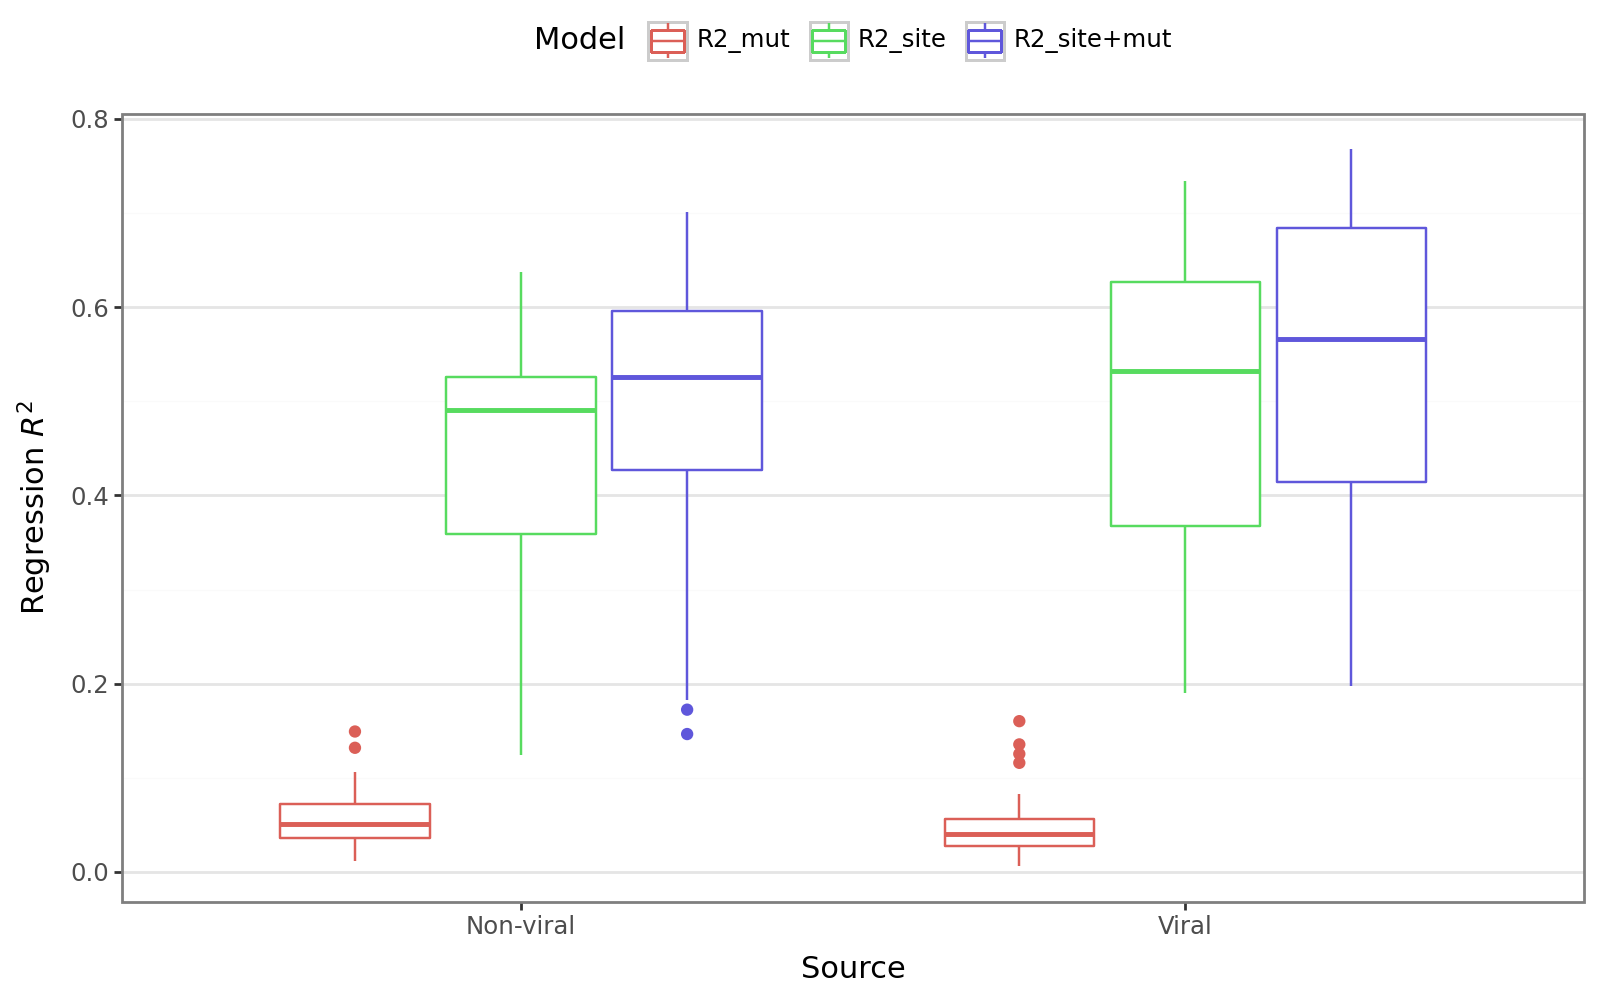

In [6]:
plot = (
    pln.ggplot(res_melt, pln.aes(y='R2', x='Source', color='Model'))
    + pln.geom_boxplot()
    + pln.theme_bw()
    + pln.theme(figure_size=(8,5), panel_grid_major_x=pln.element_blank(), legend_position='top')
    +pln.labs(
        y='Regression $R^2$'
    )
    )

plot#.save('../experiments/regression/regression_site_categorical.png', dpi=600)

# diff pool-ss x R2

In [7]:
df_vn = pd.read_csv('../experiments/viral_nonviral_splits_lassoCV_results.csv', index_col=0)
#df_vn['diff'] = abs(df_vn['Random'] - df_vn['Site Split'])
df_vn['diff'] = df_vn['Random'] - df_vn['Site Split']
df_vn.rename(columns={'dataset':'Dataset'}, inplace=True)
df_vn

,Dataset,Source,Random,Site Split,diff
0,AMIE_PSEAE_Whitehead,Non-viral,0.299995,0.123492,0.176503
1,B3VI55_LIPSTSTABLE,Non-viral,0.288673,0.066101,0.222572
2,B3VI55_LIPST_Whitehead2015,Non-viral,0.132217,0.021192,0.111025
3,BG_STRSQ_hmmerbit,Non-viral,0.513594,-0.038098,0.551692
4,BLAT_ECOLX_Ostermeier2014,Non-viral,0.567648,0.361909,0.205739
...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,Non-viral,0.143554,0.022154,0.121399
70,TPMT_HUMAN_Fowler2018,Non-viral,0.526532,0.410842,0.115690
71,UBC9_HUMAN_Roth2017,Non-viral,0.436062,-0.203271,0.639333
72,UBE4B_MOUSE_Klevit2013_singles,Non-viral,0.296340,0.011835,0.284505


In [8]:
res = df_vn.merge(res_melt.query('Model=="R2_site"'), how='left', on=['Dataset', 'Source'])
res['diff_norm'] = (res['diff'] - res['diff'].min()) / (res['diff'].max() - res['diff'].min())
res

,Dataset,Source,Random,Site Split,diff,Model,R2,diff_norm
0,AMIE_PSEAE_Whitehead,Non-viral,0.299995,0.123492,0.176503,R2_site,0.4708,0.203410
1,B3VI55_LIPSTSTABLE,Non-viral,0.288673,0.066101,0.222572,R2_site,0.3559,0.258270
2,B3VI55_LIPST_Whitehead2015,Non-viral,0.132217,0.021192,0.111025,R2_site,0.2583,0.125438
3,BG_STRSQ_hmmerbit,Non-viral,0.513594,-0.038098,0.551692,R2_site,0.3626,0.650195
4,BLAT_ECOLX_Ostermeier2014,Non-viral,0.567648,0.361909,0.205739,R2_site,0.5522,0.238226
...,...,...,...,...,...,...,...,...
69,TPK1_HUMAN_Roth2017,Non-viral,0.143554,0.022154,0.121399,R2_site,0.1473,0.137792
70,TPMT_HUMAN_Fowler2018,Non-viral,0.526532,0.410842,0.115690,R2_site,0.3431,0.130992
71,UBC9_HUMAN_Roth2017,Non-viral,0.436062,-0.203271,0.639333,R2_site,0.4037,0.754561
72,UBE4B_MOUSE_Klevit2013_singles,Non-viral,0.296340,0.011835,0.284505,R2_site,0.3766,0.332022


In [15]:
correlation = res['diff'].corr(res['R2'])
print("Correlation:", correlation)

Correlation: 0.26593757691816805


In [16]:
0.25 * 0.25

0.0625

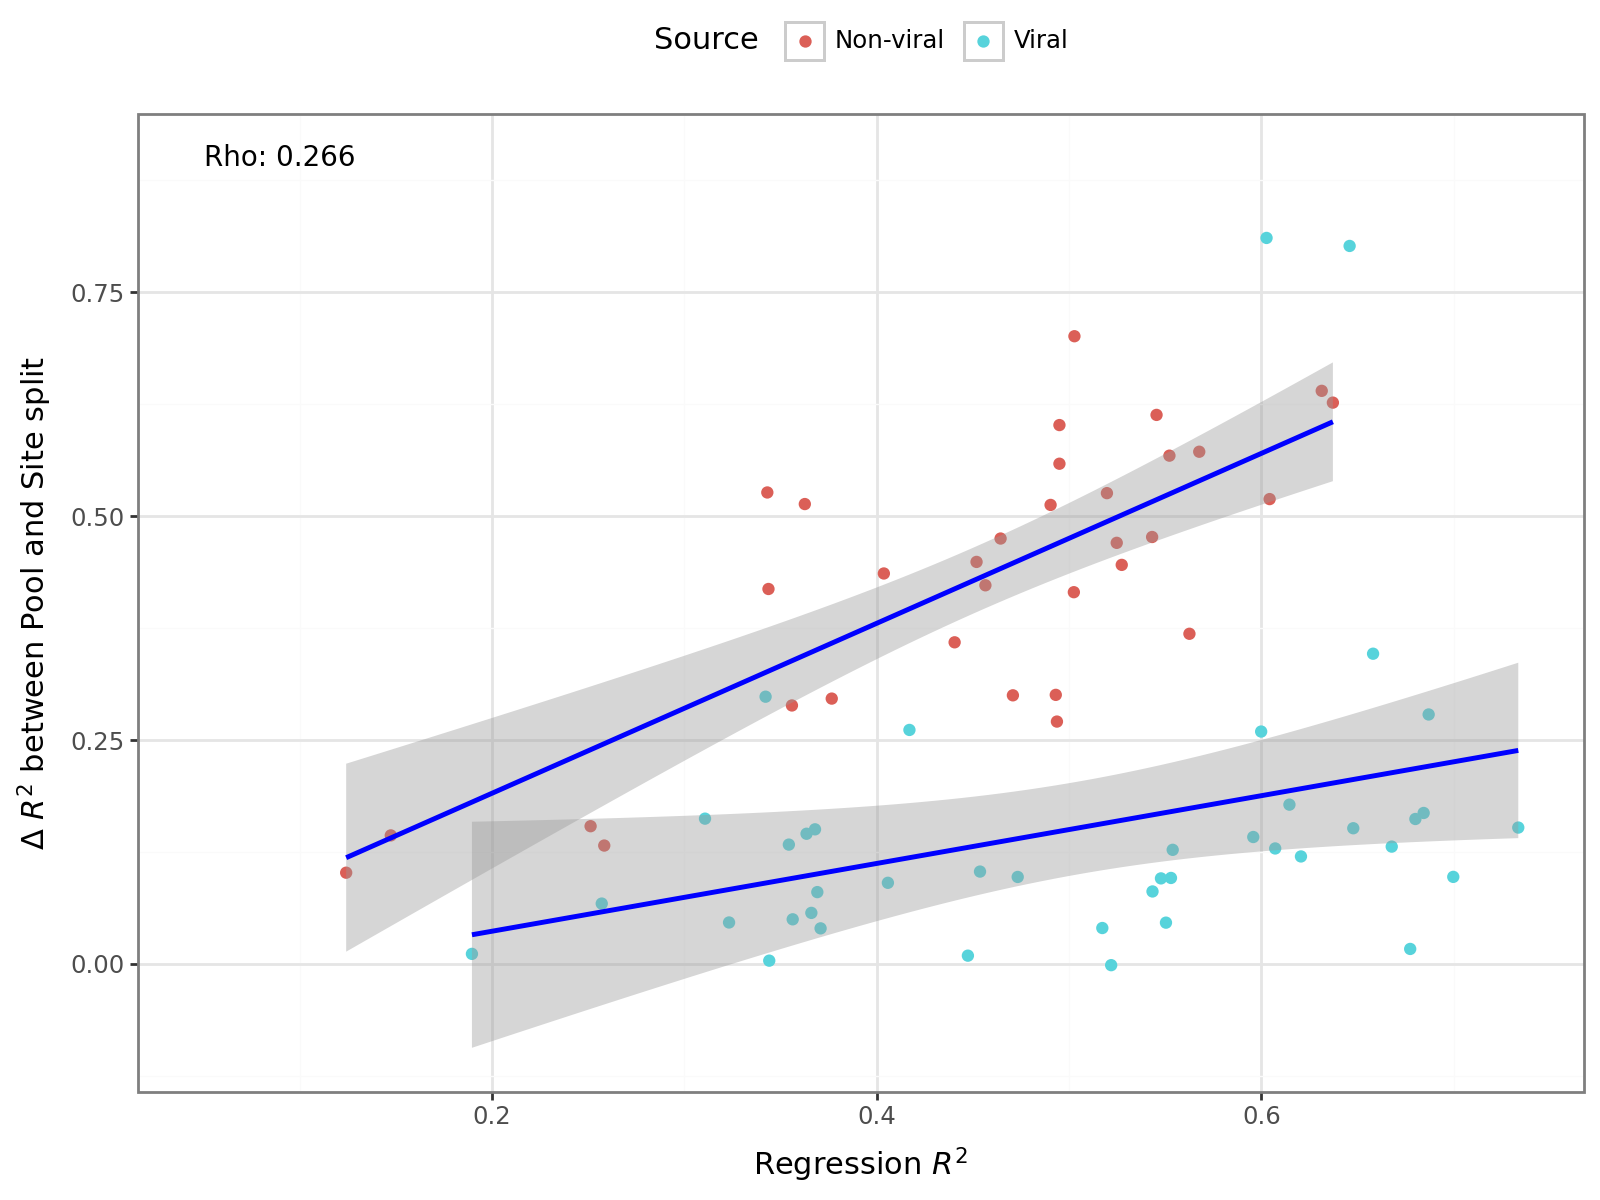

In [21]:
plot = (
    #pln.ggplot(res, pln.aes(y='diff_norm', x='R2', color='Source'))
    pln.ggplot(res, pln.aes(y='Random', x='R2', color='Source', group='Source'))
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True, color='blue')
    + pln.theme_bw()
    + pln.theme(figure_size=(8,6), legend_position='top')
    + pln.annotate('text', x=0.05, y=0.9, label=f'Rho: {correlation:.3}', ha='left', size=10) # Rho 'ρ' perasorn correlation
    #+ pln.ylim(0, 1)
    #+ pln.xlim(0, 1)
    + pln.labs(
        #x="$|\Delta|$ $R^2$ between Pool and Site split",
        y="$\Delta$ $R^2$ between Pool and Site split",
        x="Regression $R^2$"
    )
    )
plot#.save('../experiments/regression/diff_x_r2.png', dpi=600)